In [1]:
from pathlib import Path
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import pandas_datareader.data as pdr

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

from scipy.optimize import linprog
from scipy.stats import skew, kurtosis
from scipy import stats 

OUTPUT_DIR = Path("cqf_pc_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Configuration

In [2]:
ASSETS = [
    "SPY", "QQQ", "EFA", "EEM",      # equities
    "SHY", "IEF", "TIP",             # rates / inflation-linked bonds
    "LQD", "HYG",                     # credit
    "GLD", "DBC",                     # real assets / commodities
    "VNQ"                              # REITs
]

# External factor proxies: We avoid using SPY, IEF, HYG, LQD or DBC directly as factor proxies because they are investable assets.

EQUITY_FACTOR_ETF = "VT"        # broad global equity proxy
COMMODITY_FACTOR_ETF = "GSG"    # broad commodity proxy; avoids using DBC directly
DURATION_FACTOR_ETF = "TLT"     # long Treasury ETF, not in investable universe; used only as diagnostic proxy fallback
CREDIT_FACTOR_ETF = "JNK"       # high-yield ETF, not in investable universe; used only as diagnostic proxy fallback

FRED_RF = "DTB3"                # 3M Treasury Bill rate, percent p.a.
                
ROLLING_WINDOW=60               # We use last 60 months of data for estimations  

HAC_LAGS = 6

TAU = 0.05

# Rebalancing cadence for the walk-forward backtest.
REBALANCE_FREQUENCY_MONTHS = 3         
TOP_N = 3
BOTTOM_N = 3

MAX_WEIGHT = 0.40

DATA_CUTOFF = pd.Timestamp("2026-07-31")

## Data Preparation and Return Construction

In [3]:
def download_yahoo_adjusted_close(tickers):
    """ Download adjusted close prices using yfinance API for provided list of Assets.
    Drops all null values and provides prices starting from dates available for all assets"""
    data=yf.download(tickers,period="max")
    data.dropna(inplace=True)
    px=data['Close'].copy()
    px=px[tickers]
    px.sort_index(inplace=True)
    return px

def daily_returns(daily_px_df):
    return daily_px_df.pct_change().dropna()

def monthly_returns(daily_px_df):
    return daily_px_df.resample('ME').last().pct_change().dropna()

###  Investable Asset Universe

In [4]:
# Downloading Asset Prices
asset_prices=download_yahoo_adjusted_close(ASSETS)
asset_prices = asset_prices.loc[:DATA_CUTOFF].copy()
print(asset_prices.index.min(),asset_prices.index.max())
asset_prices.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  12 of 12 completed

2007-04-11 00:00:00 2026-07-31 00:00:00


Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-11,101.122383,37.893616,43.530628,26.826187,57.445843,50.522144,56.019497,49.675953,31.394184,67.080002,20.637650,35.494057
2007-04-12,101.571709,38.193615,43.821289,27.274706,57.438694,50.571175,56.019497,49.750732,31.415243,66.989998,20.759480,35.252514
2007-04-13,102.035095,38.270767,43.966614,27.408588,57.410019,50.485336,55.879749,49.666626,31.358091,67.839996,20.873184,35.650620
2007-04-16,103.004021,38.622185,44.430534,27.734385,57.402855,50.540535,56.058708,49.708702,31.346050,68.400002,20.710751,35.695354
2007-04-17,103.277893,38.707886,44.436108,27.584877,57.496044,50.755135,56.092213,49.979683,31.331022,68.000000,20.499580,36.160557


In [5]:
START_DATE=asset_prices.index.min().date()
START_DATE

datetime.date(2007, 4, 11)

### Daily and Monthly Asset Returns

In [6]:
# Asset Daily and Monthly Returns
asset_daily_returns=daily_returns(asset_prices)
print("Asset Daily Returns")
display(asset_daily_returns.head())

asset_monthly_returns=monthly_returns(asset_prices)
print("Asset Monthly Returns")
display(asset_monthly_returns.head())

Asset Daily Returns


Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-12,0.004443,0.007917,0.006677,0.016719,-0.000124,0.000970,0.000000,0.001505,0.000671,-0.001342,0.005903,-0.006805
2007-04-13,0.004562,0.002020,0.003316,0.004909,-0.000499,-0.001697,-0.002495,-0.001691,-0.001819,0.012688,0.005477,0.011293
2007-04-16,0.009496,0.009182,0.010552,0.011887,-0.000125,0.001093,0.003203,0.000847,-0.000384,0.008255,-0.007782,0.001255
2007-04-17,0.002659,0.002219,0.000125,-0.005391,0.001623,0.004246,0.000598,0.005451,-0.000479,-0.005848,-0.010196,0.013033
2007-04-18,0.001224,-0.003321,-0.000377,-0.007442,0.001372,0.002295,0.003288,0.000280,0.000288,0.005588,0.000396,-0.006185


Asset Monthly Returns


Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-05-31,0.033920,0.031550,0.023623,0.050645,-0.000675,-0.013935,-0.013115,-0.012307,0.003731,-0.023103,-0.002346,-0.003785
2007-06-30,-0.014620,0.004792,-0.003209,0.036784,0.004751,-0.004677,-0.002148,-0.008100,-0.031523,-0.019378,0.007448,-0.090077
2007-07-31,-0.031311,-0.001470,-0.022905,0.007141,0.009040,0.022568,0.023008,-0.008241,-0.038802,0.023650,0.019066,-0.082594
2007-08-31,0.012833,0.028193,-0.006336,0.010410,0.010489,0.022631,0.008221,0.023861,0.051940,0.011096,-0.019091,0.067446
2007-09-30,0.038714,0.052522,0.053175,0.115715,0.005519,0.000883,0.012805,0.007334,0.029225,0.105081,0.094200,0.039173


### Risk-Free Rate and Excess Returns

In [7]:
# Downloading Risk-Free Rate
rf = pdr.DataReader(FRED_RF,"fred",start=START_DATE)
rf = rf.loc[:DATA_CUTOFF].copy()
rf=rf/100
rf.dropna(inplace=True)
rf.columns=['RF']
print("Rf",rf.index.min(),rf.index.max())
display(rf.head())

Rf 2007-04-11 00:00:00 2026-07-31 00:00:00


,RF
DATE,
2007-04-11,0.0490
2007-04-12,0.0489
2007-04-13,0.0488
2007-04-16,0.0488
2007-04-17,0.0487


In [8]:
# Monthly Risk Free Rates 
rf_monthly=rf.resample('ME').last()
print("Rf",rf_monthly.index.min(),rf_monthly.index.max())
display(rf_monthly.head())

# Deannualising rates to calcualte excess returns
rf_monthly_deannualised=((1 + rf_monthly)**(1/12)) - 1
print("Rf",rf_monthly_deannualised.index.min(),rf_monthly_deannualised.index.max())
display(rf_monthly_deannualised.head())

Rf 2007-04-30 00:00:00 2026-07-31 00:00:00


,RF
DATE,
2007-04-30,0.0479
2007-05-31,0.0460
2007-06-30,0.0468
2007-07-31,0.0482
2007-08-31,0.0391


Rf 2007-04-30 00:00:00 2026-07-31 00:00:00


,RF
DATE,
2007-04-30,0.003907
2007-05-31,0.003755
2007-06-30,0.003819
2007-07-31,0.003931
2007-08-31,0.003201


In [9]:
rf_monthly_deannualised=rf_monthly_deannualised.reindex(asset_monthly_returns.index)
rf_monthly_deannualised.head()

,RF
Date,
2007-05-31,0.003755
2007-06-30,0.003819
2007-07-31,0.003931
2007-08-31,0.003201
2007-09-30,0.003048


In [10]:
asset_monthly_excess_returns=asset_monthly_returns.sub(rf_monthly_deannualised["RF"],axis=0)
asset_monthly_excess_returns.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-05-31,0.030165,0.027795,0.019868,0.046890,-0.004430,-0.017690,-0.016870,-0.016062,-0.000024,-0.026858,-0.006101,-0.007540
2007-06-30,-0.018439,0.000973,-0.007027,0.032965,0.000933,-0.008496,-0.005967,-0.011919,-0.035342,-0.023196,0.003629,-0.093896
2007-07-31,-0.035242,-0.005401,-0.026835,0.003210,0.005109,0.018638,0.019077,-0.012172,-0.042732,0.019720,0.015136,-0.086524
2007-08-31,0.009632,0.024991,-0.009537,0.007209,0.007288,0.019430,0.005020,0.020660,0.048739,0.007894,-0.022293,0.064244
2007-09-30,0.035666,0.049474,0.050127,0.112666,0.002471,-0.002165,0.009757,0.004286,0.026176,0.102033,0.091152,0.036124


### Diagnostic Factor Proxies

In [11]:
# Downloading Proxy Factors Prices
factor_etfs_px=download_yahoo_adjusted_close([EQUITY_FACTOR_ETF, CREDIT_FACTOR_ETF, DURATION_FACTOR_ETF,COMMODITY_FACTOR_ETF])
factor_etfs_px = factor_etfs_px.loc[:DATA_CUTOFF].copy()
print("Factors ETFs:",factor_etfs_px.index.min(),factor_etfs_px.index.max())
display(factor_etfs_px.head())

# Proxy Factors Daily and Monthly Returns
factor_daily_returns=daily_returns(factor_etfs_px)
print("Proxy Factors Daily Returns")
display(factor_daily_returns.head())

factor_monthly_returns=monthly_returns(factor_etfs_px)
print("Proxy Factors Monthly Returns")
display(factor_monthly_returns.head())

[*********************100%***********************]  4 of 4 completed

Factors ETFs: 2008-06-26 00:00:00 2026-07-31 00:00:00


Ticker,VT,JNK,TLT,GSG
Date,,,,
2008-06-26,33.874275,37.027256,52.785454,74.510002
2008-06-27,33.819622,37.154202,53.404392,74.730003
2008-06-30,33.846954,37.196522,53.415958,74.910004
2008-07-01,33.546322,37.157276,53.289398,74.949997
2008-07-02,33.054413,36.875717,53.568047,76.379997


Proxy Factors Daily Returns


Ticker,VT,JNK,TLT,GSG
Date,,,,
2008-06-27,-0.001613,0.003428,0.011726,0.002953
2008-06-30,0.000808,0.001139,0.000217,0.002409
2008-07-01,-0.008882,-0.001055,-0.002369,0.000534
2008-07-02,-0.014664,-0.007577,0.005229,0.019079
2008-07-03,0.002687,0.003702,-0.002167,-0.000393


Proxy Factors Monthly Returns


Ticker,VT,JNK,TLT,GSG
Date,,,,
2008-07-31,-0.026847,-0.011147,-0.003673,-0.133227
2008-08-31,-0.018461,-0.002199,0.027392,-0.074850
2008-09-30,-0.091082,-0.076175,0.014759,-0.104378
2008-10-31,-0.214368,-0.190863,-0.018606,-0.296654
2008-11-30,-0.068068,-0.083809,0.143413,-0.148784


In [12]:
factor_monthly_returns["Credit"]=factor_monthly_returns["JNK"]-factor_monthly_returns["TLT"]
factor_monthly_returns.drop(["JNK"],axis=1,inplace=True)
factor_monthly_returns.rename({"VT":"Equity","TLT":"Duration","GSG":"Commodity"},axis=1,inplace=True)
factor_monthly_returns.head()

Ticker,Equity,Duration,Commodity,Credit
Date,,,,
2008-07-31,-0.026847,-0.003673,-0.133227,-0.007474
2008-08-31,-0.018461,0.027392,-0.074850,-0.029591
2008-09-30,-0.091082,0.014759,-0.104378,-0.090934
2008-10-31,-0.214368,-0.018606,-0.296654,-0.172257
2008-11-30,-0.068068,0.143413,-0.148784,-0.227223


In [13]:
factor_monthly_excess_returns=factor_monthly_returns[["Equity","Duration","Commodity"]].copy()
rf_aligned_temp=rf_monthly_deannualised["RF"].reindex(factor_monthly_excess_returns.index)
factor_monthly_excess_returns=factor_monthly_excess_returns.sub(rf_aligned_temp,axis=0)
factor_monthly_excess_returns["Credit"]=factor_monthly_returns["Credit"].copy()
factor_monthly_excess_returns.head()

Ticker,Equity,Duration,Commodity,Credit
Date,,,,
2008-07-31,-0.028212,-0.005038,-0.134591,-0.007474
2008-08-31,-0.019858,0.025995,-0.076247,-0.029591
2008-09-30,-0.091829,0.014012,-0.105125,-0.090934
2008-10-31,-0.214734,-0.018972,-0.297020,-0.172257
2008-11-30,-0.068076,0.143405,-0.148793,-0.227223


## Understanding Asset–Factor Relationships

### Rolling Multi-Factor Regressions

In [14]:
def rolling_regression(asset_excess_returns, factor_excess_returns,window=ROLLING_WINDOW):
    # Align both DataFrames
    asset_excess_returns=asset_excess_returns.reindex(factor_excess_returns.index)
    
    # Create dicstionaries to store model results and parameters
    params_all, tstats_all, r2_all = {}, {}, {}
    
    # define exog variable and add constant to it
    X=sm.add_constant(factor_excess_returns)
    
    # get list of assets
    assets=list(asset_excess_returns.columns)
    
    # Run the rolling regression on each asset
    for asset in assets:
        y=asset_excess_returns[asset]
        model=RollingOLS(endog=y,exog=X, window=window, min_nobs=window)
        res=model.fit()
        
        # save the results
        params_all[asset]=res.params
        tstats_all[asset]=res.tvalues
        r2_all[asset]=res.rsquared
        
    # Combine the results in a dataframe
    params=pd.concat(params_all,axis=1)
    tstats=pd.concat(tstats_all,axis=1)
    rsquared=pd.concat(r2_all,axis=1)
    rsquared.columns=asset_excess_returns.columns
    
    # Drop Null Values
    params.dropna(inplace=True)
    tstats.dropna(inplace=True)
    rsquared.dropna(inplace=True)
    
    return {"params":params, "tstats":tstats, "rsqaured":rsquared}
    

In [15]:
results=rolling_regression(asset_monthly_excess_returns,factor_monthly_excess_returns)

In [16]:
results["params"].head()

SPY                                               QQQ  \
               const    Equity  Duration Commodity    Credit     const   
Date                                                                     
2013-06-30  0.004184  0.848927 -0.129635 -0.005563 -0.070091  0.007160   
2013-07-31  0.004193  0.845414 -0.127662  0.000770 -0.070030  0.007242   
2013-08-31  0.003485  0.851119 -0.130452  0.002858 -0.073752  0.007039   
2013-09-30  0.003796  0.825952 -0.127693  0.009830 -0.067986  0.008841   
2013-10-31  0.004112  0.836275 -0.140593  0.000801 -0.078375  0.009235   

                                                    ...       DBC            \
              Equity  Duration Commodity    Credit  ...     const    Equity   
Date                                                ...                       
2013-06-30  0.733181 -0.095388 -0.032005  0.118922  ...  0.000571 -0.010984   
2013-07-31  0.727102 -0.092607 -0.019197  0.118223  ...  0.000218 -0.017192   
2013-08-31  0.717410 -0.091667 -0.008402  0.120522  ...  0.000446 -0.019841   
2013-09-30  0.718247 -0.138839 -0.021822  0.079486  ...  0.000559 -0.031370   
2013-10-31  0.730564 -0.157913 -0.034034  0.064884  ...  0.000438 -0.033222   

                                               VNQ                      \
            Duration Commodity    Credit     const    Equity  Duration   
Date                                                                     
2013-06-30  0.151278  0.755238  0.194995 -0.001688  0.710524  0.977085   
2013-07-31  0.158242  0.756295  0.199511 -0.002818  0.677696  1.006954   
2013-08-31  0.159268  0.756345  0.200954 -0.003994  0.698753  1.000540   
2013-09-30  0.161299  0.759754  0.204261 -0.006712  0.678760  1.079737   
2013-10-31  0.177452  0.766778  0.214416 -0.006481  0.684168  1.059041   

                                
           Commodity    Credit  
Date                            
2013-06-30 -0.182927  0.961023  
2013-07-31 -0.157064  0.976085  
2013-08-31 -0.164012  0.966459  
2013-09-30 -0.136903  1.037846  
2013-10-31 -0.147077  1.024053  

[5 rows x 60 columns]

In [17]:
results["rsqaured"].head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2013-06-30,0.934761,0.805188,0.966460,0.894304,0.415984,0.828810,0.616689,0.663352,0.937172,0.200430,0.940539,0.768962
2013-07-31,0.935655,0.808144,0.966619,0.889352,0.410043,0.829771,0.615965,0.661708,0.936921,0.205443,0.937833,0.769113
2013-08-31,0.939684,0.811173,0.967649,0.891796,0.410845,0.828440,0.612159,0.665401,0.938114,0.200459,0.937260,0.771351
2013-09-30,0.938018,0.826444,0.966500,0.888018,0.408373,0.828372,0.591616,0.749447,0.948603,0.219672,0.935052,0.802650
2013-10-31,0.922272,0.794580,0.962208,0.864597,0.451682,0.827981,0.468852,0.805505,0.956520,0.119240,0.912125,0.750584


### Median Factor Exposures Across Assets

In [18]:
median_betas=pd.DataFrame(results["params"].median(axis=0)).unstack()[0]
median_betas.drop("const",axis=1,inplace=True)
median_betas

,Equity,Duration,Commodity,Credit
SPY,0.992717,-0.048622,-0.064643,0.009196
QQQ,1.263427,-0.212061,-0.100405,-0.219101
EFA,0.962804,0.026646,0.016524,-0.023734
EEM,1.069687,0.115396,0.104745,-0.060197
SHY,-0.006942,0.065835,-0.000564,0.019124
IEF,-0.038252,0.518341,-0.004456,0.089746
TIP,0.054669,0.466406,0.039109,0.179371
LQD,0.063837,0.843632,0.005667,0.520226
HYG,0.004783,0.947992,-0.011543,0.949767
GLD,0.009731,0.660773,0.135691,0.291147


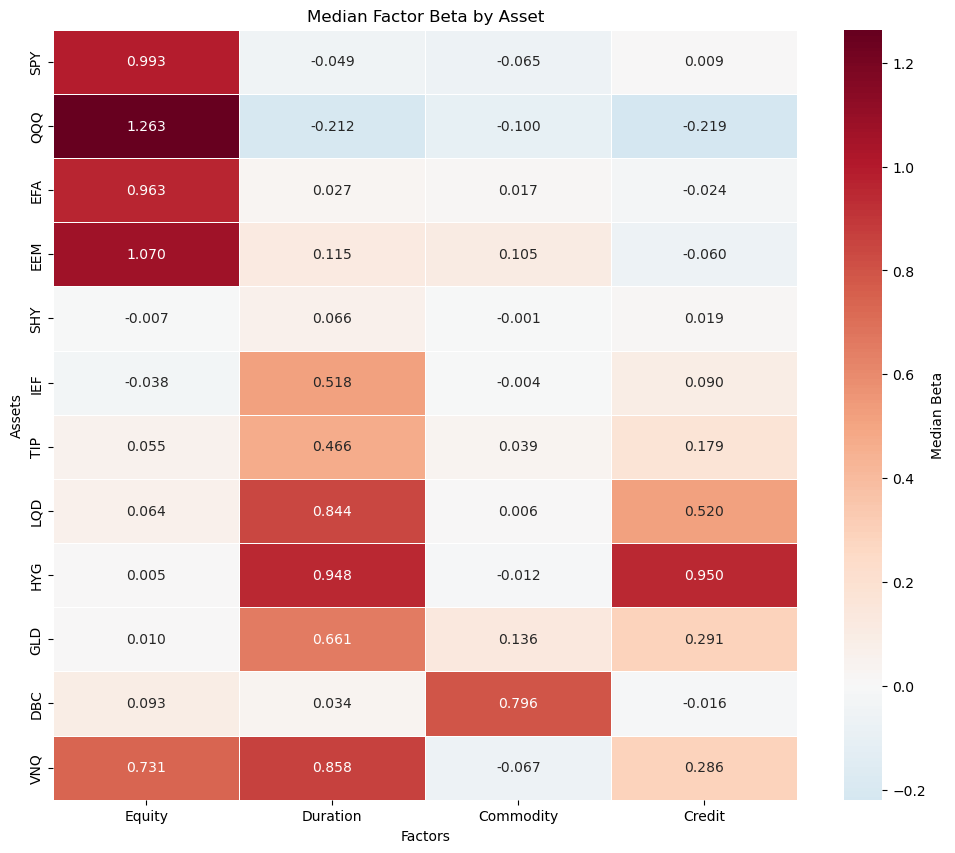

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(median_betas,annot=True,cmap="RdBu_r",fmt=".3f",center=0,linewidths=0.5,cbar_kws={"label":"Median Beta"})
plt.title("Median Factor Beta by Asset")
plt.xlabel("Factors")
plt.ylabel("Assets")
plt.show()

**Interpretation.** 
The median-beta matrix confirms that the ETF universe contains materially different economic exposures. Equity ETFs have the strongest equity loadings, fixed-income ETFs are more sensitive to duration and credit, while DBC has the clearest commodity loading.

VNQ is particularly interesting because it combines meaningful equity and duration exposure, illustrating why asset-class labels alone do not fully describe portfolio risk.

These differences support the use of a multi-asset universe rather than a collection of closely related equity securities.

### Evolution of Factor Exposures Through Time

In [20]:
# We will plot betas over time for each factor on selected representatives of various asset classes
sub_assets=["SPY",  # Equity
           "IEF",   # Government Bond
           "HYG",   # Corporate Credit
           "DBC",   # Commodities
           "VNQ"    # Real Estate
           ]

equity_factor_betas=pd.DataFrame({asset:results['params'][asset]['Equity'] for asset in sub_assets})
duration_factor_betas=pd.DataFrame({asset:results['params'][asset]['Duration'] for asset in sub_assets})
credit_factor_betas=pd.DataFrame({asset:results['params'][asset]['Credit'] for asset in sub_assets})
commodity_factor_betas=pd.DataFrame({asset:results['params'][asset]['Commodity'] for asset in sub_assets})

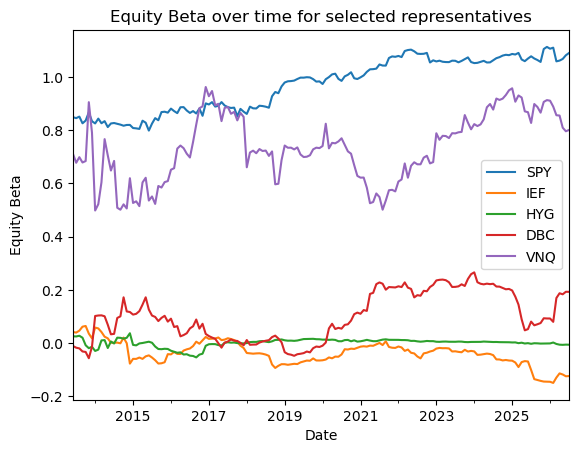

In [21]:
equity_factor_betas.plot(ylabel="Equity Beta",title="Equity Beta over time for selected representatives")
plt.show()

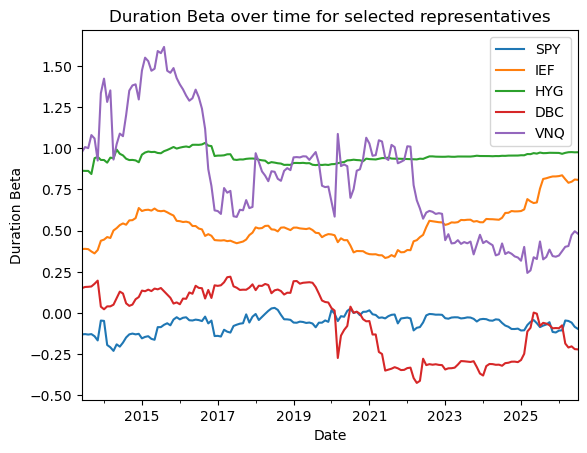

In [22]:
duration_factor_betas.plot(ylabel="Duration Beta",title="Duration Beta over time for selected representatives")
plt.show()

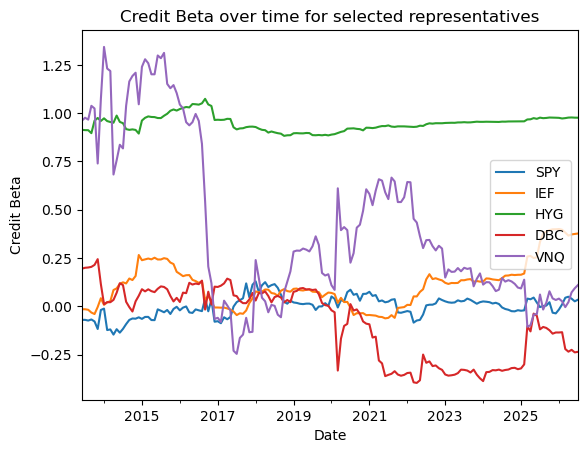

In [23]:
credit_factor_betas.plot(ylabel="Credit Beta",title="Credit Beta over time for selected representatives")
plt.show()

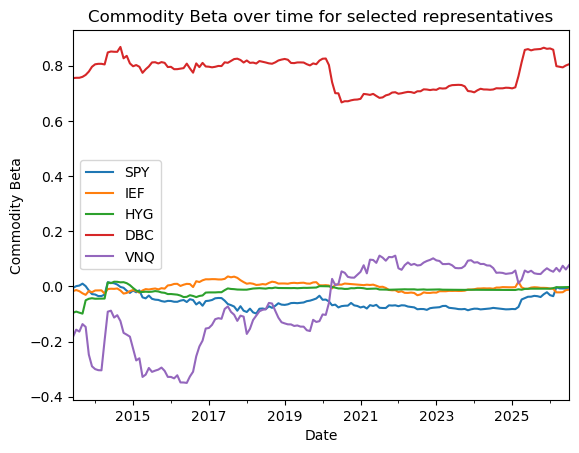

In [24]:
commodity_factor_betas.plot(ylabel="Commodity Beta",title="Commodity Beta over time for selected representatives")
plt.show()

## Candidate Signal Construction and Evaluation

### Candidate signals

Six candidate cross-sectional signals are considered:

1. **12–1 momentum:** return over the previous 12 months excluding the most recent month.
2. **6–1 momentum:** shorter-horizon momentum with the same one-month exclusion.
3. **Risk-adjusted momentum:** momentum scaled by trailing realised volatility.
4. **10-month trend:** price relative to its lagged 10-month moving average.
5. **12-month drawdown:** distance from the trailing 12-month high.
6. **Volatility-regime signal:** short-term volatility relative to its longer-run level.

The objective is not to assume that every signal is useful. Each candidate is tested using future returns before deciding which signals enter the final composite.

In [25]:
asset_monthly_prices=asset_prices.resample('ME').last()
asset_monthly_prices.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-30,104.120468,39.393600,44.246071,26.964540,57.653812,51.055538,56.656921,50.334770,31.773264,67.089996,20.767597,35.449329
2007-05-31,107.652222,40.636459,45.291298,28.330164,57.614895,50.344078,55.913841,49.715313,31.891802,65.540001,20.718868,35.315140
2007-06-30,106.078323,40.831173,45.145977,29.372250,57.888645,50.108631,55.793739,49.312595,30.886463,64.269997,20.873184,32.134052
2007-07-31,102.756874,40.771137,44.111931,29.581987,58.411961,51.239502,57.077423,48.906208,29.688009,65.790001,21.271158,29.479982
2007-08-31,104.075600,41.920589,43.832458,29.889935,59.024643,52.399101,57.546658,50.073166,31.230001,66.519997,20.865065,31.468277


### Candidate Signal Definitions

In [26]:
def signal_generation_engine(monthly_prices):
    """
    Takes monthly prices as input
    Returns 12-1 Mom, 6-1 Mom, Risk_adj Mom, Trend, Drawdown, Signal Serieses
    """
    monthly_returns=monthly_prices.pct_change()
    
    # Mom signals
    mom_12_1=monthly_prices.shift(1)/monthly_prices.shift(13) - 1
    
    mom_6_1=monthly_prices.shift(1)/monthly_prices.shift(7) - 1
    
    vol_12_1=monthly_returns.shift(1).rolling(12).std()
    
    ram_12_1 = mom_12_1 / vol_12_1
    
    # Trend
    ma_10_lagged=monthly_prices.shift(1).rolling(window=10,min_periods=10).mean()
    
    trend_10m = monthly_prices / ma_10_lagged - 1
    
    # Drawdown
    high_12m=monthly_prices.rolling(window=12,min_periods=12).max()
    
    drawdown_12m=monthly_prices / high_12m - 1
    
    # Vol-Regime
    short_vol=monthly_returns.shift(1).rolling(window=3,min_periods=3).std() * np.sqrt(12)
    
    long_vol=short_vol.rolling(window=36,min_periods=36).median()
    
    vol_regime_signal=-(short_vol/long_vol)
    
    signals={"mom_12_1":mom_12_1, "mom_6_1":mom_6_1, "ram_12_1":ram_12_1,
            "trend_10m":trend_10m, "drawdown_12m":drawdown_12m, "vol_regime_signal":vol_regime_signal}
    
    return signals

In [27]:
signals=signal_generation_engine(asset_monthly_prices)

In [28]:
# First available date for all signals
common_signal_start_date=max([signals[signal].dropna().index.min().date() for signal in signals.keys()])
common_signal_start_date

datetime.date(2010, 7, 31)

In [29]:
# Last available date for all signals
common_signal_end_date=min([signals[signal].dropna().index.max().date() for signal in signals.keys()])
common_signal_end_date

datetime.date(2026, 7, 31)

In [30]:
def align_signals(signals_df,start,end):
    align_signals=signals_df.copy()
    
    for signal in align_signals.keys():
        align_signals[signal]=align_signals[signal].loc[start:end]
        
    return align_signals        

In [31]:
signals_aligned=align_signals(signals,start=common_signal_start_date,end=common_signal_end_date)

In [32]:
forward_returns=asset_monthly_returns.shift(-1).dropna()

In [33]:
print("Aligned Signals Date Range",common_signal_start_date,common_signal_end_date)
print("forward returns date range",forward_returns.index.min().date(),forward_returns.index.max().date())

Aligned Signals Date Range 2010-07-31 2026-07-31
forward returns date range 2007-05-31 2026-06-30


In [34]:
valid_dates=signals_aligned['mom_12_1'].index.intersection(forward_returns.index)
forward_returns=forward_returns.loc[valid_dates]
signals_aligned={signal:signals[signal].loc[valid_dates] for signal in signals_aligned.keys()}

In [35]:
print("Aligned Signals Date Range",signals_aligned['mom_12_1'].index.min().date(),signals_aligned['mom_12_1'].index.max().date())
print("forward returns date range",forward_returns.index.min().date(),forward_returns.index.max().date())

Aligned Signals Date Range 2010-07-31 2026-06-30
forward returns date range 2010-07-31 2026-06-30


### Cross-Sectional Information Coefficient

In [36]:
def spearman_ic(signal_df,forward_returns):
    valid_dates=signal_df.index.intersection(forward_returns.index)
    
    ic_values={}
    
    for date in valid_dates:
        data=pd.concat([signal_df.loc[date].rename("signal"),
                       forward_returns.loc[date].rename("forward_return")],axis=1).dropna()
        ic_values[date]=data["signal"].corr(data["forward_return"],method="spearman")
        
    return pd.Series(ic_values).sort_index()

In [37]:
ic_series={}

for signal,signal_df in signals_aligned.items():
    ic_series[signal]=spearman_ic(signal_df,forward_returns)
    
ic_df=pd.DataFrame(ic_series)
ic_df.head()

,mom_12_1,mom_6_1,ram_12_1,trend_10m,drawdown_12m,vol_regime_signal
2010-07-31,-0.041958,0.839161,0.636364,0.391608,0.647789,0.391608
2010-08-31,0.307692,0.020979,-0.699301,-0.552448,-0.848383,-0.601399
2010-09-30,-0.132867,-0.349650,-0.762238,0.174825,-0.245467,-0.685315
2010-10-31,0.097902,-0.048951,0.153846,0.055944,0.075258,-0.146853
2010-11-30,0.055944,-0.307692,-0.713287,0.426573,-0.091068,-0.454545


In [38]:
def summarize_ic(ic_series):
    ic=ic_series.dropna()
    
    mean_ic=ic.mean()
    median_ic=ic.median()
    std_ic=ic.std()
    
    icir=(mean_ic/std_ic if std_ic>0 else np.nan)
    
    ic_hit_rate=(ic>0).mean() * 100
    
    return pd.Series({"Mean IC":mean_ic, "Median IC":median_ic,
                     "IC Std":std_ic, "ICIR":icir, "IC Hit Rate": ic_hit_rate, "N Months":len(ic)})

In [39]:
ic_summary=pd.DataFrame({signal:summarize_ic(ic_df[signal]) for signal in ic_df.columns}).T
ic_summary

,Mean IC,Median IC,IC Std,ICIR,IC Hit Rate,N Months
mom_12_1,0.085519,0.101399,0.432245,0.197848,57.812500,192.0
mom_6_1,0.080237,0.080420,0.447134,0.179448,56.250000,192.0
ram_12_1,0.009251,0.031469,0.438428,0.021101,50.520833,192.0
trend_10m,0.090399,0.139860,0.433514,0.208526,60.937500,192.0
drawdown_12m,0.041818,0.036978,0.447946,0.093354,52.083333,192.0
vol_regime_signal,-0.029174,-0.052448,0.350756,-0.083174,45.833333,192.0


In [40]:
ic_summary = ic_summary.sort_values("Mean IC", ascending=False)
ic_summary

,Mean IC,Median IC,IC Std,ICIR,IC Hit Rate,N Months
trend_10m,0.090399,0.139860,0.433514,0.208526,60.937500,192.0
mom_12_1,0.085519,0.101399,0.432245,0.197848,57.812500,192.0
mom_6_1,0.080237,0.080420,0.447134,0.179448,56.250000,192.0
drawdown_12m,0.041818,0.036978,0.447946,0.093354,52.083333,192.0
ram_12_1,0.009251,0.031469,0.438428,0.021101,50.520833,192.0
vol_regime_signal,-0.029174,-0.052448,0.350756,-0.083174,45.833333,192.0


### Statistical Significance of Signal IC

In [41]:
def hac_mean_ic_test(ic_series,maxlags=5):
    ic=ic_series.dropna()
    
    maxlags=min(maxlags, len(ic)-1)
    
    X=np.ones((len(ic),1))
    model=sm.OLS(ic.values,X).fit(cov_type="HAC",cov_kwds={"maxlags":maxlags})
    
    return model.tvalues[0],model.pvalues[0]

In [42]:
for signal in ic_summary.index:

    tstat, pvalue = hac_mean_ic_test(
        ic_df[signal],
        maxlags=HAC_LAGS
    )

    ic_summary.loc[signal, "HAC_tstat"] = tstat
    ic_summary.loc[signal, "HAC_pvalue"] = pvalue
ic_summary

,Mean IC,Median IC,IC Std,ICIR,IC Hit Rate,N Months,HAC_tstat,HAC_pvalue
trend_10m,0.090399,0.139860,0.433514,0.208526,60.937500,192.0,2.675354,0.007465
mom_12_1,0.085519,0.101399,0.432245,0.197848,57.812500,192.0,2.447045,0.014403
mom_6_1,0.080237,0.080420,0.447134,0.179448,56.250000,192.0,2.247978,0.024578
drawdown_12m,0.041818,0.036978,0.447946,0.093354,52.083333,192.0,1.352104,0.176342
ram_12_1,0.009251,0.031469,0.438428,0.021101,50.520833,192.0,0.255653,0.798219
vol_regime_signal,-0.029174,-0.052448,0.350756,-0.083174,45.833333,192.0,-1.156575,0.247446


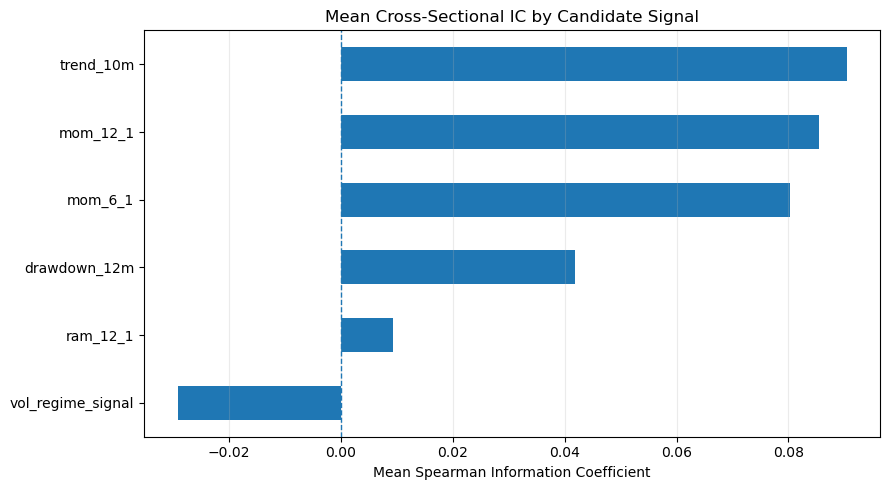

In [43]:
# Candidate Signal Mean IC Comparison

signal_ic_plot = (ic_summary["Mean IC"].sort_values())

ax = signal_ic_plot.plot(kind="barh",figsize=(9, 5))

ax.axvline(0,linewidth=1,linestyle="--")

ax.set_title("Mean Cross-Sectional IC by Candidate Signal")

ax.set_xlabel("Mean Spearman Information Coefficient")

ax.set_ylabel("")

ax.grid(axis="x",alpha=0.25)

plt.tight_layout()
plt.show()

**Candidate-signal results.** Trend and the two momentum signals provide the strongest evidence of cross-sectional predictability.

- Trend: mean IC ≈ 0.090, HAC t-stat ≈ 2.68
- 12–1 momentum: mean IC ≈ 0.086, HAC t-stat ≈ 2.45
- 6–1 momentum: mean IC ≈ 0.080, HAC t-stat ≈ 2.25

Risk-adjusted momentum, drawdown and the volatility-regime signal provide materially weaker evidence. The final signal set is therefore restricted to the two momentum signals and trend.

### Final Signal Selection

In [44]:
SELECTED_SIGNALS = [
    "mom_12_1",
    "mom_6_1",
    "trend_10m"
]

In [45]:
HAC_LAG_GRID = [1, 3, 6, 12]

hac_sensitivity = []

for signal in SELECTED_SIGNALS:
    
    for lag in HAC_LAG_GRID:
        
        tstat, pvalue = hac_mean_ic_test(
            ic_df[signal],
            maxlags=lag
        )
        
        hac_sensitivity.append({
            "Signal": signal,
            "Maxlags": lag,
            "HAC_tstat": tstat,
            "HAC_pvalue": pvalue
        })

hac_sensitivity = pd.DataFrame(hac_sensitivity)

In [46]:
hac_tstat_table = hac_sensitivity.pivot(
    index="Maxlags",
    columns="Signal",
    values="HAC_tstat"
)

hac_tstat_table.round(3)

Signal,mom_12_1,mom_6_1,trend_10m
Maxlags,,,
1,2.665,2.408,2.801
3,2.527,2.346,2.710
6,2.447,2.248,2.675
12,2.377,2.145,2.753


In [47]:
hac_pvalue_table = hac_sensitivity.pivot(
    index="Maxlags",
    columns="Signal",
    values="HAC_pvalue"
)

hac_pvalue_table.round(3)

Signal,mom_12_1,mom_6_1,trend_10m
Maxlags,,,
1,0.008,0.016,0.005
3,0.012,0.019,0.007
6,0.014,0.025,0.007
12,0.017,0.032,0.006


## Signal Persistence and Forecast Horizon

In [48]:
# Checking signal persistence to determine rebalance frequency of our portfolios
def calculate_signal_persistence(signal_df,max_lag=12):
    results=[]
    
    for lag in range(1, max_lag+1):
        correlations=[]
        
        for i in range(len(signal_df)-lag):
            current_signal=signal_df.iloc[i]
            future_signal=signal_df.iloc[i + lag]
            
            corr=current_signal.corr(future_signal,method="spearman")
            correlations.append(corr)
        
        correlations=pd.Series(correlations).dropna()
        
        results.append({"Lag_Months":lag,
                       "Mean_Rank_Corr":correlations.mean(),
                       "Median_Rank_Corr":correlations.median(),
                        "Pct_Positive":(correlations>0).mean() * 100,
                        "N_Observations":len(correlations)})
    
    return pd.DataFrame(results)

In [49]:
persistence_results = {}

for signal in SELECTED_SIGNALS:
    
    persistence_results[signal] = calculate_signal_persistence(
        signals_aligned[signal],
        max_lag=12
    )


In [50]:
persistence_table = pd.DataFrame({
    signal: df.set_index("Lag_Months")["Mean_Rank_Corr"]
    for signal, df in persistence_results.items()
})

persistence_table.round(3)

,mom_12_1,mom_6_1,trend_10m
Lag_Months,,,
1,0.883,0.783,0.815
2,0.807,0.640,0.694
3,0.738,0.508,0.588
4,0.664,0.386,0.496
5,0.603,0.283,0.421
6,0.543,0.170,0.356
7,0.487,0.164,0.299
8,0.437,0.162,0.245
9,0.363,0.151,0.194


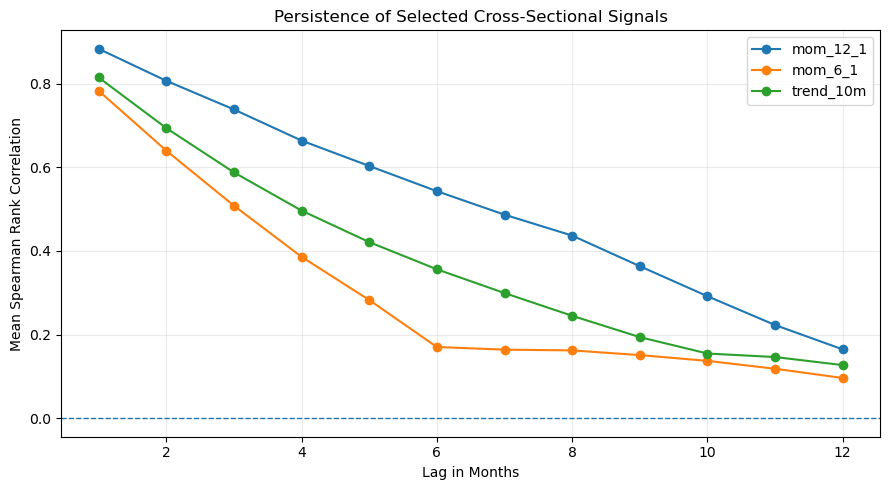

In [51]:
ax = persistence_table.plot(figsize=(9, 5),marker="o")

ax.axhline(0,linewidth=1,linestyle="--")

ax.set_title("Persistence of Selected Cross-Sectional Signals")

ax.set_xlabel("Lag in Months")

ax.set_ylabel("Mean Spearman Rank Correlation")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

**Rebalancing implication.** The selected signals decay gradually rather than disappearing after one month. At a three-month lag, rank persistence remains approximately:

- 0.74 for 12–1 momentum,
- 0.51 for 6–1 momentum, and
- 0.59 for trend.

This provides a practical argument for quarterly rather than monthly rebalancing: the signal rankings remain informative while unnecessary portfolio turnover can be reduced.

### Cumulative Forward-Return Horizon

In [52]:
HORIZONS = [1, 2, 3, 6]

def calculate_cumulative_forward_ic(signal_df,monthly_prices,horizons):
    """
    Measures relationship between signal at t and
    cumulative return from t to t+h.
    """
    
    results = []

    for h in horizons:

        # Cumulative return over next h months
        forward_h_return = (monthly_prices.shift(-h) / monthly_prices - 1)

        dates = signal_df.index.intersection(forward_h_return.index)

        ic_values = []

        for date in dates:

            data = pd.concat([signal_df.loc[date].rename("signal"),forward_h_return.loc[date].rename("forward_return")],axis=1).dropna()

            if len(data) == 0:
                continue

            ic = data["signal"].corr(data["forward_return"],method="spearman")

            ic_values.append(ic)

        ic_values = pd.Series(ic_values).dropna()

        results.append({
            "Horizon_Months": h,
            "Mean_IC": ic_values.mean(),
            "Median_IC": ic_values.median(),
            "IC_Hit_Rate": (ic_values > 0).mean() * 100,
            "N_Months": len(ic_values)
        })

    return pd.DataFrame(results)

In [53]:
cumulative_ic_results = {}

for signal in SELECTED_SIGNALS:

    cumulative_ic_results[signal] = calculate_cumulative_forward_ic(signals_aligned[signal],asset_monthly_prices,HORIZONS)

In [54]:
cumulative_ic_table = pd.DataFrame({signal: df.set_index("Horizon_Months")["Mean_IC"] for signal, df in cumulative_ic_results.items()})

cumulative_ic_table.round(3)

,mom_12_1,mom_6_1,trend_10m
Horizon_Months,,,
1,0.086,0.080,0.090
2,0.111,0.087,0.103
3,0.126,0.103,0.127
6,0.171,0.164,0.181


### Month-by-Month IC Decay

In [55]:
def calculate_ic_decay(signal_df,monthly_returns,horizons):
    """
    Measures how long a signal formed at t continues
    to predict individual future monthly returns.

    h = 1: return in next month
    h = 2: return in second month after signal
    h = 3: return in third month after signal
    etc.
    """

    results = []

    for h in horizons:

        # Monthly return occurring h months after signal formation
        future_month_return = monthly_returns.shift(-h)

        dates = signal_df.index.intersection(future_month_return.index)

        ic_values = []

        for date in dates:

            data = pd.concat([signal_df.loc[date].rename("signal"),future_month_return.loc[date].rename("future_return")],axis=1).dropna()

            if len(data) == 0:
                continue

            ic = data["signal"].corr(data["future_return"],method="spearman")

            ic_values.append(ic)

        ic_values = pd.Series(ic_values).dropna()

        results.append({
            "Horizon_Months": h,
            "Mean_IC": ic_values.mean(),
            "Median_IC": ic_values.median(),
            "IC_Hit_Rate": (ic_values > 0).mean() * 100,
            "N_Months": len(ic_values)
        })

    return pd.DataFrame(results)

In [56]:
IC_DECAY_HORIZONS = [1, 2, 3, 4, 5, 6, 9, 12]

ic_decay_results = {}

for signal in SELECTED_SIGNALS:

    ic_decay_results[signal] = calculate_ic_decay(signals_aligned[signal],asset_monthly_returns,IC_DECAY_HORIZONS)
    
ic_decay_table = pd.DataFrame({signal: df.set_index("Horizon_Months")["Mean_IC"] for signal, df in ic_decay_results.items()})

ic_decay_table.round(3)

,mom_12_1,mom_6_1,trend_10m
Horizon_Months,,,
1,0.086,0.080,0.090
2,0.076,0.082,0.081
3,0.073,0.083,0.087
4,0.083,0.091,0.082
5,0.090,0.087,0.076
6,0.100,0.068,0.087
9,0.029,0.030,0.048
12,0.054,0.057,0.032


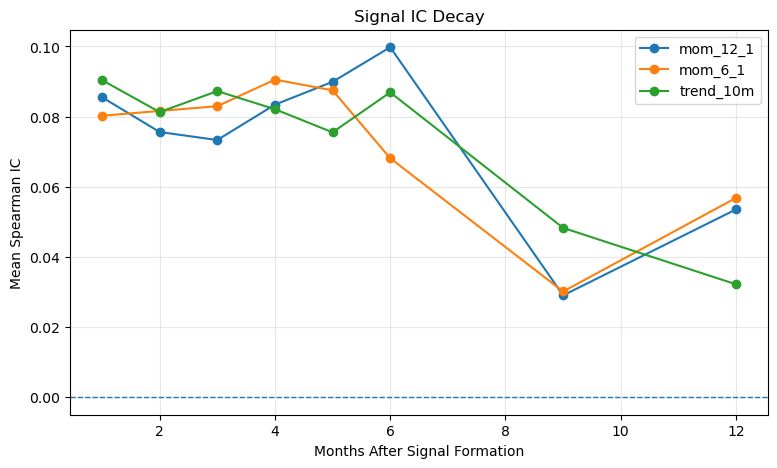

In [57]:
ax = ic_decay_table.plot(marker="o",figsize=(9, 5))

ax.axhline(0,linewidth=1,linestyle="--")

ax.set_title("Signal IC Decay")
ax.set_xlabel("Months After Signal Formation")
ax.set_ylabel("Mean Spearman IC")
ax.grid(alpha=0.3)

plt.show()

## Economic Validation Using Top-minus-Bottom Portfolios

In [58]:
def calculate_top_bottom_spread(signal_df,forward_returns,top_n=TOP_N):
    
    dates = signal_df.index.intersection(forward_returns.index)

    spreads = {}

    for date in dates:

        data = pd.concat([signal_df.loc[date].rename("signal"),forward_returns.loc[date].rename("forward_return")],axis=1).dropna()

        # Need enough assets to form distinct top and bottom baskets
        if len(data) < 2 * top_n:
            continue

        data = data.sort_values("signal")

        bottom = data.head(top_n)
        top = data.tail(top_n)

        spreads[date] = (top["forward_return"].mean() - bottom["forward_return"].mean())

    return pd.Series(spreads).sort_index()

In [59]:
spread_series = {}

for signal_name, signal_df in signals_aligned.items():

    spread_series[signal_name] = calculate_top_bottom_spread(signal_df=signal_df,forward_returns=forward_returns,top_n=TOP_N)

spread_df = pd.DataFrame(spread_series)
spread_df

,mom_12_1,mom_6_1,ram_12_1,trend_10m,drawdown_12m,vol_regime_signal
2010-07-31,0.019570,0.073212,0.057773,0.025537,0.059547,0.046528
2010-08-31,0.007698,0.007698,-0.084290,-0.060959,-0.082381,-0.072281
2010-09-30,0.005997,-0.012153,-0.032109,0.014362,-0.006005,-0.038442
2010-10-31,0.022695,0.015422,0.013547,0.012000,0.007788,0.004945
2010-11-30,-0.020973,-0.033767,-0.074915,0.046827,-0.003182,-0.043088
...,...,...,...,...,...,...
2026-02-28,-0.066644,-0.079956,-0.078443,-0.084511,0.029011,-0.004645
2026-03-31,0.022002,0.045607,-0.050793,-0.054111,-0.058965,0.004398
2026-04-30,0.002796,-0.049085,-0.001826,0.038813,-0.020959,0.052720
2026-05-31,-0.031109,-0.069723,-0.035612,-0.033007,0.070594,0.004003


In [60]:
def summarize_spread(spread_series):

    x = spread_series.dropna()

    return pd.Series({
        "Mean_Monthly_Spread": x.mean(),
        "Median_Monthly_Spread": x.median(),
        "Pct_Positive_Spread": (x > 0).mean() * 100,
        "Annualized_Mean_Spread": x.mean() * 12,
        "Annualized_Vol": x.std() * np.sqrt(12),
        "N_Months": len(x)
    })

In [61]:
spread_summary = pd.DataFrame({signal: summarize_spread(spread_df[signal]) for signal in spread_df.columns}).T

spread_summary.round(3)

,Mean_Monthly_Spread,Median_Monthly_Spread,Pct_Positive_Spread,Annualized_Mean_Spread,Annualized_Vol,N_Months
mom_12_1,0.006,0.004,55.208,0.067,0.123,192.0
mom_6_1,0.003,0.003,56.250,0.041,0.124,192.0
ram_12_1,0.002,0.002,51.562,0.018,0.124,192.0
trend_10m,0.004,0.006,57.292,0.045,0.128,192.0
drawdown_12m,0.001,0.000,51.562,0.016,0.128,192.0
vol_regime_signal,-0.002,-0.003,45.312,-0.028,0.100,192.0


In [62]:
cumulative_spread = (1 + spread_df).cumprod()

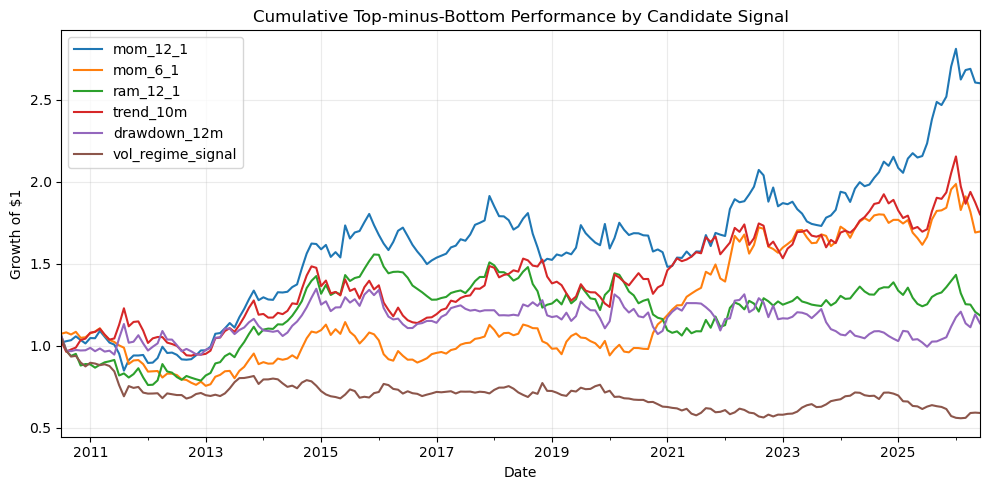

In [63]:
ax = cumulative_spread.plot(figsize=(10, 5))

ax.set_title("Cumulative Top-minus-Bottom Performance by Candidate Signal")

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Rolling Signal Stability

In [64]:
rolling_ic_12m = (ic_df.rolling(window=12, min_periods=12).mean())

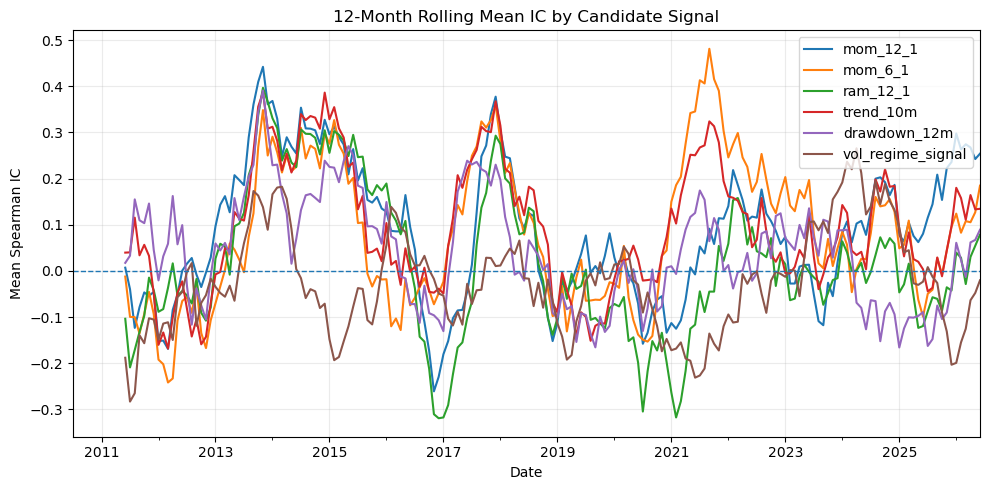

In [65]:
ax = rolling_ic_12m.plot(figsize=(10, 5))

ax.axhline(0,linewidth=1,linestyle="--")

ax.set_title("12-Month Rolling Mean IC by Candidate Signal")

ax.set_xlabel("Date")
ax.set_ylabel("Mean Spearman IC")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

The rolling IC analysis shows that signal effectiveness varies through time. This is expected for systematic return predictors and argues against interpreting the full-sample mean IC as a constant forecasting relationship.

## Construction of the Final Composite Signal

The final signal is designed to combine related information without optimising weights in-sample.

The 12–1 and 6–1 momentum signals are first standardised cross-sectionally and combined into a single **momentum family**. This avoids giving momentum twice the influence simply because two momentum horizons were tested.

The final score is then:

composite_Score= 0.5 * (Momentum Family + Trend)

This creates an equal balance between two conceptually distinct sources of information: momentum and trend.

In [66]:
# Final Composite Signal Construction

def cross_sectional_Zscore(df):

    mean = df.mean(axis=1)
    std = df.std(axis=1, ddof=0).replace(0, np.nan)

    return df.sub(mean, axis=0).div(std, axis=0)


# Final selected signals only
SELECTED_SIGNALS = [
    "mom_12_1",
    "mom_6_1",
    "trend_10m"
]


# Determine common availability based ONLY on selected signals
selected_signal_start = max(signals[s].dropna().index.min() for s in SELECTED_SIGNALS)

selected_signal_end = min(signals[s].dropna().index.max() for s in SELECTED_SIGNALS)


selected_signals_aligned = {s: signals[s].loc[selected_signal_start:selected_signal_end].copy() for s in SELECTED_SIGNALS}


print("Final selected-signal range:",selected_signal_start.date(),"to",selected_signal_end.date())

Final selected-signal range: 2008-05-31 to 2026-07-31


In [67]:
mom_12_z = cross_sectional_Zscore(selected_signals_aligned["mom_12_1"])

mom_12_z.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2008-05-31,-0.921248,-0.441796,-0.731318,0.751102,-0.154744,0.086052,0.104335,-0.389386,-0.565666,1.124932,2.496381,-1.358644
2008-06-30,-0.927570,-0.286656,-0.734328,0.477034,-0.198887,0.000101,0.120765,-0.436691,-0.580333,1.130102,2.641792,-1.205329
2008-07-31,-0.920370,-0.589953,-0.839613,-0.178858,-0.113796,0.119675,0.231109,-0.306272,-0.418080,1.261433,2.692289,-0.937564
2008-08-31,-1.017449,-0.649607,-1.063024,-0.486454,-0.091349,0.152116,0.215455,-0.252811,-0.225204,1.460355,2.549679,-0.591706
2008-09-30,-0.897988,-0.574162,-1.145601,-0.733269,0.086420,0.347216,0.461312,-0.188608,-0.373956,1.043696,2.639457,-0.664517


In [68]:
mom_6_z = cross_sectional_Zscore(selected_signals_aligned["mom_6_1"])

mom_6_z.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2008-05-31,-0.909253,-1.293753,-0.911220,-1.038918,0.314384,0.619360,0.623064,0.179156,-0.116647,0.838917,2.352994,-0.658084
2008-06-30,-0.774886,-0.568874,-0.827192,-0.422772,-0.167422,-0.201064,-0.026170,-0.406507,-0.358156,0.838146,3.022614,-0.107716
2008-07-31,-0.895815,-0.901932,-0.844177,-0.688138,0.068034,0.124671,0.308738,-0.148989,-0.331426,0.694946,2.896172,-0.282083
2008-08-31,-0.909879,0.071585,-0.876006,-0.715241,0.058034,-0.018836,0.104797,-0.448045,-0.203935,-0.227345,3.094241,0.070631
2008-09-30,-0.127333,1.363069,-1.098468,-1.592112,0.306321,0.342666,0.347968,-0.059827,0.235105,-1.892815,0.939046,1.236381


In [69]:
trend_z = cross_sectional_Zscore(selected_signals_aligned["trend_10m"])

trend_z.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2008-05-31,-0.791113,-0.179051,-0.627651,0.066125,-0.348399,-0.349138,-0.085839,-0.587602,-0.407208,0.407809,3.154664,-0.252598
2008-06-30,-0.849972,-0.646523,-0.801129,-0.540942,0.056375,0.104982,0.314361,-0.210472,-0.310307,0.731370,2.922816,-0.770559
2008-07-31,-1.035796,-0.571670,-1.286801,-1.285546,0.390987,0.471053,0.578192,0.007132,-0.100037,0.875194,2.373503,-0.416212
2008-08-31,-0.519206,-0.016692,-1.679322,-2.043442,0.758422,0.973679,0.962313,0.304354,0.075505,-0.508604,1.343964,0.349028
2008-09-30,-0.500619,-0.845959,-1.368214,-1.874306,1.245409,1.245244,0.788437,-0.288965,-0.375040,0.724141,0.180094,1.069778


In [70]:
# Equal-weight the two standardized momentum signals
momentum_family = (mom_12_z + mom_6_z) / 2

momentum_family.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2008-05-31,-0.915250,-0.867774,-0.821269,-0.143908,0.079820,0.352706,0.363699,-0.105115,-0.341157,0.981924,2.424687,-1.008364
2008-06-30,-0.851228,-0.427765,-0.780760,0.027131,-0.183155,-0.100482,0.047298,-0.421599,-0.469245,0.984124,2.832203,-0.656522
2008-07-31,-0.908093,-0.745942,-0.841895,-0.433498,-0.022881,0.122173,0.269924,-0.227631,-0.374753,0.978189,2.794230,-0.609824
2008-08-31,-0.963664,-0.289011,-0.969515,-0.600848,-0.016658,0.066640,0.160126,-0.350428,-0.214569,0.616505,2.821960,-0.260538
2008-09-30,-0.512660,0.394453,-1.122034,-1.162690,0.196371,0.344941,0.404640,-0.124218,-0.069426,-0.424559,1.789251,0.285932


In [71]:
# 50% Momentum Family + 50% Trend
composite_score = (momentum_family + trend_z) / 2

composite_score.head()

Ticker,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2008-05-31,-0.853182,-0.523413,-0.724460,-0.038891,-0.134290,0.001784,0.138930,-0.346358,-0.374182,0.694867,2.789676,-0.630481
2008-06-30,-0.850600,-0.537144,-0.790945,-0.256906,-0.063390,0.002250,0.180829,-0.316036,-0.389776,0.857747,2.877510,-0.713541
2008-07-31,-0.971944,-0.658806,-1.064348,-0.859522,0.184053,0.296613,0.424058,-0.110249,-0.237395,0.926692,2.583866,-0.513018
2008-08-31,-0.741435,-0.152851,-1.324418,-1.322145,0.370882,0.520159,0.561219,-0.023037,-0.069532,0.053950,2.082962,0.044245
2008-09-30,-0.506640,-0.225753,-1.245124,-1.518498,0.720890,0.795093,0.596538,-0.206591,-0.222233,0.149791,0.984673,0.677855


## Mapping Signal Scores into Black–Litterman Views

The composite signal is dimensionless, whereas a Black–Litterman view must be expressed as an expected return. The next stage therefore measures the score difference between the highest- and lowest-ranked asset groups and studies the realised return spread that historically followed a similar score gap.

In [72]:
def build_score_spread_panel(composite_score,monthly_prices,horizon=REBALANCE_FREQUENCY_MONTHS,top_n=TOP_N):

    forward_h_returns = (monthly_prices.shift(-horizon) / monthly_prices - 1)

    dates = composite_score.index.intersection(forward_h_returns.index)

    results = []

    for date in dates:

        data = pd.concat([composite_score.loc[date].rename("score"),forward_h_returns.loc[date].rename("forward_return")],axis=1).dropna()

        # Skip dates without sufficient future-return data
        if len(data) < 2 * top_n:
            continue

        data = data.sort_values("score")

        bottom = data.head(top_n)
        top = data.tail(top_n)

        score_gap = (top["score"].mean() - bottom["score"].mean())

        realized_spread = (top["forward_return"].mean() - bottom["forward_return"].mean())

        results.append({"Date": date,"Score_Gap": score_gap,"Realized_Spread": realized_spread})

    return (pd.DataFrame(results).set_index("Date").sort_index())

In [73]:
spread_panel_3m = build_score_spread_panel(
    composite_score=composite_score,
    monthly_prices=asset_monthly_prices,
    horizon=REBALANCE_FREQUENCY_MONTHS,
    top_n=TOP_N
)

spread_panel_3m.describe()

,Score_Gap,Realized_Spread
count,216.000000,216.000000
mean,2.239696,0.014086
std,0.192954,0.071914
min,1.404805,-0.381606
25%,2.141241,-0.027649
50%,2.269085,0.020440
75%,2.381328,0.056905
max,2.591341,0.204276


Using the historical relationship between score gaps and subsequent three-month Top-minus-Bottom returns gives:

- mean-based (k = 0.0252)
- median-ratio (k = 0.0343)

A rounded value of \(k=0.025\) is retained for the portfolio stage.

In [74]:
# Full-sample calibration of the Black-Litterman view scale k

# Mean-based mapping from score gap to realised 3-month spread
full_sample_mean_k = (spread_panel_3m["Realized_Spread"].mean() / spread_panel_3m["Score_Gap"].mean() * 12 / REBALANCE_FREQUENCY_MONTHS)


# Median of period-by-period mappings
full_sample_median_k = ((spread_panel_3m["Realized_Spread"] / spread_panel_3m["Score_Gap"]).median() * 12 / REBALANCE_FREQUENCY_MONTHS)


pd.Series({"Mean-based annual k":full_sample_mean_k,
           "Median period-ratio annual k":full_sample_median_k})

Mean-based annual k             0.025158
Median period-ratio annual k    0.034334
dtype: float64

### Composite Signal IC Validation

In [75]:
# Explicitly use ONE-MONTH forward returns for IC analysis
forward_returns_1m = (asset_monthly_returns.shift(-1).dropna(how="all"))


composite_ic = spearman_ic(composite_score,forward_returns_1m)

composite_ic.head()

2008-05-31    0.804196
2008-06-30   -0.279720
2008-07-31   -0.300699
2008-08-31    0.622378
2008-09-30    0.321678
dtype: float64

In [76]:
composite_ic_summary = summarize_ic(composite_ic)

composite_ic_summary

Mean IC          0.082280
Median IC        0.122378
IC Std           0.445748
ICIR             0.184589
IC Hit Rate     58.256881
N Months       218.000000
dtype: float64

In [77]:
hac_tstat, hac_pvalue = hac_mean_ic_test(
    composite_ic,
    maxlags=HAC_LAGS
)

composite_ic_summary["HAC_tstat"] = hac_tstat
composite_ic_summary["HAC_pvalue"] = hac_pvalue

composite_ic_summary

Mean IC          0.082280
Median IC        0.122378
IC Std           0.445748
ICIR             0.184589
IC Hit Rate     58.256881
N Months       218.000000
HAC_tstat        2.527418
HAC_pvalue       0.011490
dtype: float64

In [78]:
ic_comparison = {}


for signal in SELECTED_SIGNALS:

    signal_ic = spearman_ic(selected_signals_aligned[signal],forward_returns_1m)

    summary = summarize_ic(signal_ic)

    tstat, pvalue = hac_mean_ic_test(signal_ic,maxlags=HAC_LAGS)

    summary["HAC_tstat"] = tstat
    summary["HAC_pvalue"] = pvalue

    ic_comparison[signal] = summary


# Composite
summary = summarize_ic(composite_ic)

tstat, pvalue = hac_mean_ic_test(composite_ic,maxlags=HAC_LAGS)

summary["HAC_tstat"] = tstat
summary["HAC_pvalue"] = pvalue

ic_comparison["composite"] = summary


ic_comparison = pd.DataFrame(ic_comparison).T


ic_comparison.round(3)

,Mean IC,Median IC,IC Std,ICIR,IC Hit Rate,N Months,HAC_tstat,HAC_pvalue
mom_12_1,0.072,0.091,0.448,0.160,56.881,218.0,2.171,0.030
mom_6_1,0.077,0.077,0.460,0.168,55.963,218.0,2.361,0.018
trend_10m,0.090,0.140,0.448,0.200,61.009,218.0,2.886,0.004
composite,0.082,0.122,0.446,0.185,58.257,218.0,2.527,0.011


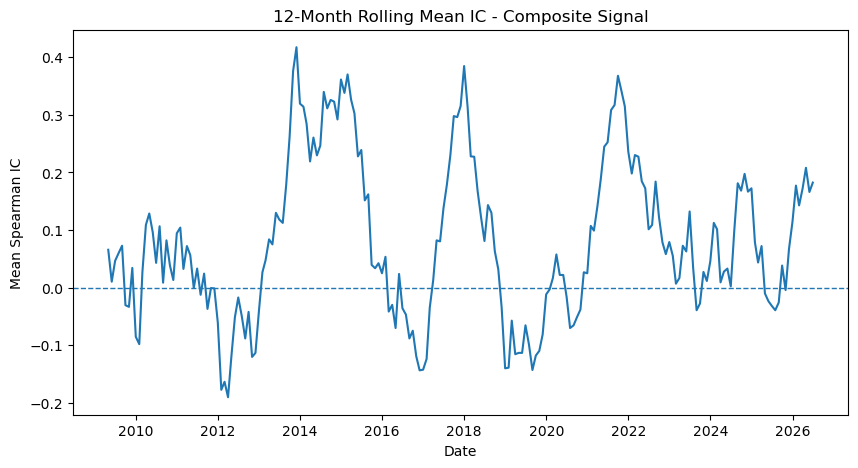

In [79]:
composite_rolling_ic_12m = (composite_ic.rolling(window=12,min_periods=12).mean())

plt.figure(figsize=(10,5))

plt.plot(composite_rolling_ic_12m.index,composite_rolling_ic_12m)

plt.axhline(0,linestyle="--",linewidth=1)

plt.title("12-Month Rolling Mean IC - Composite Signal")

plt.ylabel("Mean Spearman IC")
plt.xlabel("Date")

plt.show()

## View-Scale Calibration and Stability Checks

### Non-Overlapping Quarterly Samples

In [80]:
# View-Scale Stability Check
# Non-overlapping quarterly calibration

quarterly_k_results = []

for offset in range(REBALANCE_FREQUENCY_MONTHS):

    # Take every third monthly observation
    quarterly_panel = spread_panel_3m.iloc[
        offset::REBALANCE_FREQUENCY_MONTHS
    ].copy()

    # Mean-based calibration
    k_period = (
        quarterly_panel["Realized_Spread"].mean()
        / quarterly_panel["Score_Gap"].mean()
    )

    k_annual = (
        k_period
        * 12
        / REBALANCE_FREQUENCY_MONTHS
    )

    # Median period-by-period ratio as diagnostic
    period_ratios = (
        quarterly_panel["Realized_Spread"]
        / quarterly_panel["Score_Gap"]
    )

    k_median_annual = (
        period_ratios.median()
        * 12
        / REBALANCE_FREQUENCY_MONTHS
    )

    quarterly_k_results.append({
        "Offset": offset,
        "N_Observations": len(quarterly_panel),
        "Mean_Score_Gap": quarterly_panel["Score_Gap"].mean(),
        "Mean_3M_Spread": quarterly_panel["Realized_Spread"].mean(),
        "Mean_Based_Annual_k": k_annual,
        "Median_Ratio_Annual_k": k_median_annual
    })


quarterly_k_results = pd.DataFrame(
    quarterly_k_results
).set_index("Offset")

quarterly_k_results.round(4)

,N_Observations,Mean_Score_Gap,Mean_3M_Spread,Mean_Based_Annual_k,Median_Ratio_Annual_k
Offset,,,,,
0,72,2.2389,0.0215,0.0385,0.0409
1,72,2.2388,0.0042,0.0074,0.0291
2,72,2.2414,0.0166,0.0295,0.0171


In [81]:
# Summary of full-sample and quarterly-offset calibrations

k_robustness_summary = pd.concat([pd.DataFrame({"Mean_Based_Annual_k":[full_sample_mean_k],
                                                "Median_Ratio_Annual_k":[full_sample_median_k]},
                                               index=["All Monthly Observations"]),
                                  quarterly_k_results[["Mean_Based_Annual_k","Median_Ratio_Annual_k"]].rename(index=lambda x:f"Quarterly Offset {x}")])


k_robustness_summary.round(4)

,Mean_Based_Annual_k,Median_Ratio_Annual_k
All Monthly Observations,0.0252,0.0343
Quarterly Offset 0,0.0385,0.0409
Quarterly Offset 1,0.0074,0.0291
Quarterly Offset 2,0.0295,0.0171


**Calibration stability.** The estimated \(k\) varies across the three non-overlapping quarterly starting offsets. Mean-based estimates range from approximately 0.007 to 0.039.

This indicates that the mapping from signal magnitude to realised return magnitude is considerably noisier than the directional signal itself.

For this reason, \(k=0.025\) is treated as a simple and economically reasonable calibration rather than a precisely estimated structural parameter.

In [82]:
K_CANDIDATE = 0.025

## Exports

In [83]:
# EXPORT HANDOFF FOR PORTFOLIO-CONSTRUCTION NOTEBOOK

FACTOR_DEFINITIONS = {
    "Equity":
        "VT excess return",

    "Duration":
        "TLT excess return",

    "Credit":
        "JNK return minus TLT return",

    "Commodity":
        "GSG excess return"
}


BL_HANDOFF = {

    # CONFIGURATION
    
    "config": {

        "ASSETS":
            ASSETS,

        "ROLLING_WINDOW":
            ROLLING_WINDOW,

        "REBALANCE_FREQUENCY_MONTHS":
            REBALANCE_FREQUENCY_MONTHS,

        "TOP_N":
            TOP_N,

        "BOTTOM_N":
            BOTTOM_N,

        "TAU":
            TAU,

        "MAX_WEIGHT":
            MAX_WEIGHT,

        # retained for documentation / compatibility
        "VIEW_SCALE_K":
            K_CANDIDATE,

        "FACTOR_DEFINITIONS":
            FACTOR_DEFINITIONS
    },


    # ASSET DATA
    "asset_monthly_prices":
        asset_monthly_prices.copy(),

    "asset_monthly_returns":
        asset_monthly_returns.copy(),

    "asset_monthly_excess_returns":
        asset_monthly_excess_returns.copy(),


    # RISK-FREE RATE
    "rf_monthly":
        rf_monthly_deannualised[
            "RF"
        ].copy(),


    # SIGNAL DATA
    "mom_12_z":
        mom_12_z.copy(),

    "mom_6_z":
        mom_6_z.copy(),

    "trend_z":
        trend_z.copy(),

    "momentum_family":
        momentum_family.copy(),

    "composite_score":
        composite_score.copy(),

    "spread_panel_3m":
        spread_panel_3m.copy(),


    # FACTOR DATA
    "factor_etf_prices":
        factor_etfs_px.copy(),

    "factor_daily_returns":
        factor_daily_returns.copy(),

    "factor_monthly_returns":
        factor_monthly_returns.copy(),

    "factor_monthly_excess_returns":
        factor_monthly_excess_returns.copy()
}


pd.to_pickle(
    BL_HANDOFF,
    "CQF_BL_Handoff.pkl"
)


print(
    "Handoff saved successfully."
)

print(
    "Handoff keys:"
)

print(
    sorted(
        BL_HANDOFF.keys()
    )
)


print(
    "\nFactor coverage:"
)

print(
    factor_monthly_excess_returns.index.min(),
    "to",
    factor_monthly_excess_returns.index.max()
)

display(
    factor_monthly_excess_returns.head()
)

Handoff saved successfully.
Handoff keys:
['asset_monthly_excess_returns', 'asset_monthly_prices', 'asset_monthly_returns', 'composite_score', 'config', 'factor_daily_returns', 'factor_etf_prices', 'factor_monthly_excess_returns', 'factor_monthly_returns', 'mom_12_z', 'mom_6_z', 'momentum_family', 'rf_monthly', 'spread_panel_3m', 'trend_z']

Factor coverage:
2008-07-31 00:00:00 to 2026-07-31 00:00:00


Ticker,Equity,Duration,Commodity,Credit
Date,,,,
2008-07-31,-0.028212,-0.005038,-0.134591,-0.007474
2008-08-31,-0.019858,0.025995,-0.076247,-0.029591
2008-09-30,-0.091829,0.014012,-0.105125,-0.090934
2008-10-31,-0.214734,-0.018972,-0.297020,-0.172257
2008-11-30,-0.068076,0.143405,-0.148793,-0.227223
